In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import sys
import matplotlib.pyplot as plt
import matplotlib
import pickle

sys.path.append("..")

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [4]:
CKP = "/restricteddata/ukaea/checkpoints/separate_zf_first_residual_512/20250213_225802"
device = "cuda"

In [7]:
import yaml
from omegaconf import OmegaConf

from utils import load_model_and_config
from models import get_model

from dataset.cyclone import CycloneDataset

cfg = OmegaConf.create(yaml.safe_load(open(f"{CKP}/config.yaml", "r")))

# traindata = CycloneDataset(
#     active_keys=cfg.dataset.active_keys,
#     path=cfg.dataset.path,
#     split="train",
#     random_seed=cfg.seed,
#     test_ratio=0.0,
#     normalization=cfg.dataset.normalization,
#     spatial_ifft=cfg.dataset.spatial_ifft,
#     in_memory=False,
#     input_seq_length=cfg.model.input_seq_length,
#     target_seq_length=cfg.model.bundle_seq_length,
#     trajectories=cfg.dataset.training_trajectories,
# )

data = CycloneDataset(
    active_keys=cfg.dataset.active_keys,
    path=cfg.dataset.path,
    split="val",
    random_seed=cfg.seed,
    normalization=None,
    spatial_ifft=cfg.dataset.spatial_ifft,
    in_memory=False,
    bundle_seq_length=cfg.model.bundle_seq_length,
    trajectories=cfg.dataset.validation_trajectories,
    subsample=cfg.dataset.subsample,
    separate_zf=cfg.dataset.separate_zf,
    no_zf=cfg.dataset.no_zf,
)

print(f"Val: {len(data)}")

Val: 165


In [5]:
def force_aspect(ax, aspect=1):
    im = ax.get_images()
    extent = im[0].get_extent()
    ax.set_aspect(abs((extent[1] - extent[0]) / (extent[3] - extent[2])) / aspect)

def distribution_5D(x, **kwargs):
    _ = kwargs
    labels = ["vpar", "vmu", "s", "x", "y"]

    if isinstance(x, torch.Tensor):
        x = x.cpu().detach().numpy()

    comb = torch.combinations(torch.arange(5), 2).tolist()

    fig, ax = plt.subplots(5, 5, figsize=(20, 20))
    for i in range(5):
        for j in range(5):
            if [i, j] not in comb:
                ax[i, j].remove()

    c_map = matplotlib.colormaps["coolwarm"]
    c_map.set_bad("k")

    imin = -1
    for i, j in comb:
        other = tuple([o for o in range(5) if o != i and o != j])
        xx = x[0].std(other)
        xx[xx == 0] = np.nan
        ax[i, j].matshow(xx, cmap=c_map)

        if i > imin:
            ax[i, j].set_ylabel(labels[i], fontsize=20)
            ax[i, j].set_xlabel(labels[j], fontsize=20)
            imin = i

        force_aspect(ax[i, j])

    plt.show()

In [6]:
cfg.model.swin.norm_output = False
cfg.model.swin.abs_pe = False
cfg.model.swin.act_fn = "GELU"

In [7]:
model = get_model(cfg, dataset=data)
last = False
path = f"{CKP}/best.pth" if not last else f"{CKP}/ckp.pth"

model, _, _ = load_model_and_config(path, model, device)

model = model.to(device)
model = model.eval()

Parameters: 86.4M
Loading model /restricteddata/ukaea/checkpoints/separate_zf_first_residual_deep/20250221_175419/best.pth (stopped at epoch 200) with loss 0.171674


In [8]:
def compute_pearson_correlation(x, y):
    # shape of [c, ...]
    n_channels = x.shape[0]
    x = x.view(n_channels, -1)
    y = y.view(n_channels, -1)
    x = x - torch.mean(x, dim=1, keepdim=True)
    y = y - torch.mean(y, dim=1, keepdim=True)
    cov = torch.sum(x * y, dim=1)
    std_x = torch.linalg.norm(x, dim=1)
    std_y = torch.linalg.norm(y, dim=1)
    return torch.mean(cov / (std_x * std_y))

In [9]:
import torch
import numpy as np

from utils import expand_as

def invert_ifft(x):
    # invert fft on spatial
    knth = np.moveaxis(x, 0, -1).copy()
    knth = knth.view(dtype=np.complex64)
    # shift freqs to correct range
    knth = np.fft.fftn(knth, axes=(3, 4))
    knth = np.fft.ifftshift(knth, axes=(3, 4))
    knth = np.stack([knth.real, knth.imag]).squeeze().astype("float32")
    return knth

def normalize(x, file_index):
    shift, scale = 0.0, 1.0
    if cfg.dataset.normalization_scope == "sample":
        if cfg.dataset.normalization == "zscore":
            shift = x.mean((2, 3, 4, 5, 6), keepdims=True)
            scale = x.std((2, 3, 4, 5, 6), keepdims=True)
        if cfg.dataset.normalization == "minmax":
            x_min = x.min((2, 3, 4, 5, 6), keepdims=True)
            x_max = x.max((2, 3, 4, 5, 6), keepdims=True)
            shift = x_min
            scale = x_max - x_min
    if cfg.dataset.normalization_scope == "dataset":
        if cfg.dataset.normalization == "zscore":
            shift = expand_as(data.dataset_stats[file_index]["mean"][None], x)
            scale = expand_as(data.dataset_stats[file_index]["std"][None], x)
        if cfg.dataset.normalization == "minmax":
            x_min = expand_as(data.dataset_stats[file_index]["min"][None], x)
            x_max = expand_as(data.dataset_stats[file_index]["max"][None], x)
            shift = x_min
            scale = x_max - x_min
        scale = torch.tensor(scale, device=x.device)
        shift = torch.tensor(shift, device=x.device)
    return (x - shift) / scale, shift, scale

In [10]:
ONESTEP = False
cyclone_name = '_'.join(data.files[0].split('/')[-1].split('.')[0].split('_')[:-1])
OUT_DIR = f"{CKP}/{'onestep' if ONESTEP else 'autoreg'}/{cyclone_name}/{'best' if not last else 'ckp'}"
os.makedirs(OUT_DIR, exist_ok=True)
IDX_0 = 0
IDX_END = len(data) - 2

In [11]:
def modify_fds_dat(path):
    with open(path, 'r') as infile:
        content = infile.read()
        content = content.replace("DTIM    =  2.000000000000000E-002", "DTIM    =  0.0")
        content = content.replace("NT_REMAIN       =           0", "NT_REMAIN       =           1")
        content = content.replace("TIME    =   192.753733197446     ", "TIME    =   0")

    with open(path, 'w') as outfile:
        outfile.write(content)

In [12]:
def modify_input_dat(path):
    with open(path, 'r') as infile:
        content = infile.read()
        content = content.replace("READ_FILE  = .false.", "READ_FILE  = .true.")
        content = content.replace("DTIM   = 0.02", "DTIM   = 0.0")
        content = content.replace("out3d_interval = 3", "out3d_interval = 1")
        content = content.replace("keep_dumps = .true.", "! keep_dumps = .true.")
        content = content.replace("ndump_ts = 3", "! ndump_ts = 3")
        
    with open(path, 'w') as outfile:
        outfile.write(content)

In [17]:
losses = []
sample_0 = data[IDX_0]
xt = sample_0.x.to(device).unsqueeze(0)
itg = sample_0.itg.to(device).unsqueeze(0)
f_idx = sample_0.file_index.item()
timesteps = data.get_timesteps(torch.tensor([0], dtype=torch.long))
files = []
gt_corr = {}
model_corr = {}

with torch.no_grad():
    for idx in range(IDX_0, IDX_END + 1):
        if ONESTEP:
            xt = data[idx].x.to(device).unsqueeze(0)
            
        yt = data[idx].y.to(device).unsqueeze(0)
        ts = timesteps[:, idx].to(device)
        xt, shift, scale = normalize(xt, f_idx)
        yt, gt_shift, gt_scale = normalize(yt, f_idx)
        gt_corr[ts] = compute_pearson_correlation(xt.squeeze()[:2] + xt.squeeze()[2:], yt.squeeze()[:2] + yt.squeeze()[2:])
        xt = model(xt, timestep=ts, itg=itg)
        model_corr[ts] = compute_pearson_correlation(xt.squeeze()[:2] + xt.squeeze()[2:], yt.squeeze()[:2] + yt.squeeze()[2:])
        xt = xt / xt.std((2, 3, 4, 5, 6), keepdims=True)
        # denormalize
        # Try to use GT scale and shift for autoregressive
        xt = xt * gt_scale + gt_shift

        b_xt = xt.squeeze(0).cpu().numpy()
        if cfg.dataset.spatial_ifft:
            if cfg.dataset.separate_zf:
                # zonal flow are separate channel, add them to original channel before fft 
                # gt_zf = data[idx+1].y[2:, ...].numpy()
                zf = invert_ifft(b_xt[2:, ...])
                no_zf = invert_ifft(b_xt[:2, ...])
                b_xt = np.zeros_like(zf)
                b_xt[..., 0] = zf[..., 0]
                b_xt[... ,1:] = no_zf[..., :-1]
                # zf = b_xt[2:, ...]
                # no_zf = b_xt[:2, ...]
                # b_xt = zf + no_zf
                # b_xt = invert_ifft(b_xt)
            else:
                b_xt = invert_ifft(b_xt)
        b_xt = b_xt.astype("float64").reshape(-1, order="F")
        # dump to file
        if OUT_DIR:
            dirtarget = os.path.join(OUT_DIR, f"K{str((int(idx)+1)*cfg.dataset.subsample).zfill(2)}")
            os.makedirs(dirtarget, exist_ok=True)
            ftarget = os.path.join(dirtarget, "FDS")
            os.system(f"cp {data.files[0].replace("preprocessed", "raw").replace("_ifft", "").replace("_separate_zf", "").replace(".h5", "")}/input.dat {dirtarget}")
            os.system(f"cp {data.files[0].replace("preprocessed", "raw").replace("_ifft", "").replace("_separate_zf", "").replace(".h5", "")}/FDS.dat {dirtarget}")
            modify_fds_dat(f"{dirtarget}/FDS.dat")
            modify_input_dat(f"{dirtarget}/input.dat")
            with open(ftarget, "wb") as f:
                files.append(ftarget)
                print(f"Writing file {dirtarget}")
                f.write(b_xt)
                
            os.system(f"chmod -R 777 {dirtarget}/*")

pickle.dump(model_corr, open(f"{OUT_DIR}/model_corr.pkl", "wb"))
pickle.dump(gt_corr, open(f"{OUT_DIR}/gt_corr.pkl", "wb"))

Writing file /restricteddata/ukaea/checkpoints/separate_zf_first_residual_deep/20250221_175419/autoreg/cyclone4_2_2_ifft_separate/best/K01
Writing file /restricteddata/ukaea/checkpoints/separate_zf_first_residual_deep/20250221_175419/autoreg/cyclone4_2_2_ifft_separate/best/K02
Writing file /restricteddata/ukaea/checkpoints/separate_zf_first_residual_deep/20250221_175419/autoreg/cyclone4_2_2_ifft_separate/best/K03
Writing file /restricteddata/ukaea/checkpoints/separate_zf_first_residual_deep/20250221_175419/autoreg/cyclone4_2_2_ifft_separate/best/K04
Writing file /restricteddata/ukaea/checkpoints/separate_zf_first_residual_deep/20250221_175419/autoreg/cyclone4_2_2_ifft_separate/best/K05
Writing file /restricteddata/ukaea/checkpoints/separate_zf_first_residual_deep/20250221_175419/autoreg/cyclone4_2_2_ifft_separate/best/K06
Writing file /restricteddata/ukaea/checkpoints/separate_zf_first_residual_deep/20250221_175419/autoreg/cyclone4_2_2_ifft_separate/best/K07
Writing file /restricteddat

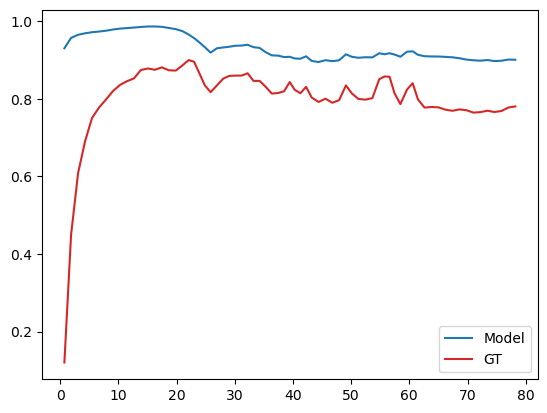

In [126]:
plt.plot([val.cpu().item() for val in model_corr.keys()], [val.cpu().item() for val in model_corr.values()], c="tab:blue", label="Model")
plt.plot([val.cpu().item() for val in gt_corr.keys()], [val.cpu().item() for val in gt_corr.values()], c="tab:red", label="GT")
plt.legend()

In [107]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation, colormaps


def force_aspect(ax, aspect=1):
    im = ax.get_images()
    extent = im[0].get_extent()
    ax.set_aspect(abs((extent[1] - extent[0]) / (extent[3] - extent[2])) / aspect)


def plot4x4_animate(kfiles, dataset, title="", frames=5, start_idx=0, average=True):
    plt.rcParams["animation.html"] = "jshtml"
    plt.ioff()

    labels = [r"v_{par}", r"v_{\mu}", r"s", r"k_x", r"k_y"]
    comb = torch.combinations(torch.arange(5), 2).tolist()

    fig, ax = plt.subplots(5, 5, figsize=(30, 12))
    for i in range(5):
        for j in range(5):
            ax[i, j].remove()

    fig.suptitle(title)
    c_map = colormaps["RdBu"]
    preds = []
    for kfname in kfiles[:frames]:
        with open(kfname, "rb") as fid:
            kt = np.fromfile(fid, dtype=np.float64)
        kt = np.reshape(kt, (2, 32, 8, 16, 255, 32), order="F").astype("float32")
        preds.append(kt)

    def animate(t):
        sample = dataset[start_idx + t]
        
        xp = preds[t]
        xgt = sample.y.numpy()
        if cfg.dataset.spatial_ifft:
            xgt = invert_ifft(xgt)
        ts = sample.timestep.numpy().item()
        fig.suptitle(f"ts={ts:.2f}", fontsize=30)

        for i, j in comb:
            other = tuple([o for o in range(5) if o != i and o != j])

            if average:
                xp_plot = xp[0].mean(other)
                xgt_plot = xgt[0].mean(other)
            else:
                xp_plot = torch.tensor(xp[0]).permute(i, j, *other).numpy()[:, :, 0, 0, 0]
                xgt_plot = torch.tensor(xgt[0]).permute(i, j, *other).numpy()[:, :, 0, 0, 0]

            ax_ij = ax[i, j]
            pos = ax_ij.get_position()

            # create two new axes within the same space as the original subplot
            plot_width = 0.475 * pos.width
            left_margin = 0.0 * pos.width
            x_left_1 = pos.x0 + left_margin
            x_left_2 = x_left_1 + plot_width
            y = pos.y0
            h = pos.height
            ax1 = fig.add_axes([x_left_1, y, plot_width, h])
            ax2 = fig.add_axes([x_left_2, y, plot_width, h])

            # compute shared vmin and vmax
            vmin = min(xgt_plot.min(), xp_plot.min())
            vmax = max(xgt_plot.max(), xp_plot.max())

            ax1.matshow(xp_plot, cmap=c_map) #, vmin=vmin, vmax=vmax)
            ax2.matshow(xgt_plot, cmap=c_map) #, vmin=vmin, vmax=vmax)

            if i == 0:
                # Set axis labels
                ax1.set_title(r"PRED", fontsize=24)
                ax2.set_title(r"GT", fontsize=24)

            if j == 1 or (i == 1 and j == 2) or (i == 2 and j == 3) or (i == 3 and j == 4):
                ax_ij.set_ylabel(rf"${labels[i]}$", fontsize=14)

            if i == 3 or j == 1 or (i == 1 and j == 2) or (i == 2 and j == 3):
                ax_ij.set_xlabel(rf"${labels[j]}$", fontsize=14)

            # Remove axis ticks and labels
            ax1.set_xticks([])
            ax1.set_yticks([])
            ax2.set_xticks([])
            ax2.set_yticks([])
            ax1.tick_params(labelleft=False, labelbottom=False)
            ax2.tick_params(labelleft=False, labelbottom=False)
            # Force aspect ratio
            force_aspect(ax1)
            force_aspect(ax2)

    return animation.FuncAnimation(fig, animate, frames=frames)

In [108]:
ani = plot4x4_animate(files, dataset=data, frames=IDX_END - IDX_0, start_idx=IDX_0)
writer = animation.PillowWriter(fps=1, bitrate=600)
ani.save("onestep.gif" if ONESTEP else "autoreg.gif", writer=writer)